In [52]:
from pathlib import Path
import re

BASE_DIR = Path("shakespeare_sonnet_stylometry_data")

roman_line_pattern = re.compile(r'^\s*[IVXLCDM]+\s*$', re.IGNORECASE | re.MULTILINE)

by_author = {}

for d in BASE_DIR.iterdir():
    file = d / "allsonnets.txt"
    
    if file.exists():
        text = file.read_text()
        
        # remove roman numerals
        text = roman_line_pattern.sub("", text)
        
        by_author[d.name] = text

for author in by_author:
    print(author)
    print(by_author[author][:100])

ShakespeareSonnets

So is it not with me as with that Muse,
Stirr’d by a painted beauty to his verse,
Who heaven itself
GemTrainedSonnets

When morning’s silver light begins to fade,
And autumn’s hand prepares the year for rest,
The vibra
PreplexitySonnets

When dawn unfolds her robes of blushing gold,
And whispers wake the slumbering fields anew,
The wor
ChatGPTSonnets

When dawn first lifts the curtain of the sky,
And pale gold spills upon the waking field,
My restle
ClaudeSonnets

When time doth lay his finger on the brow
Of she whose beauty summer hath confessed,
Shall I not cr
GemSonnets

When golden rays do touch the morning’s brow,
And wake the sleeping lilies from the field,
To Time’
CopilotSonnets

When dawn first breaks and spills her golden fire,
My thoughts ascend to realms where you abide;
Fo
GrokSonnets

ShakespeareControlSonnets

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as the r


[nltk_data] Downloading package punkt to /home/aleksander-
[nltk_data]     elkins/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/aleksander-
[nltk_data]     elkins/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


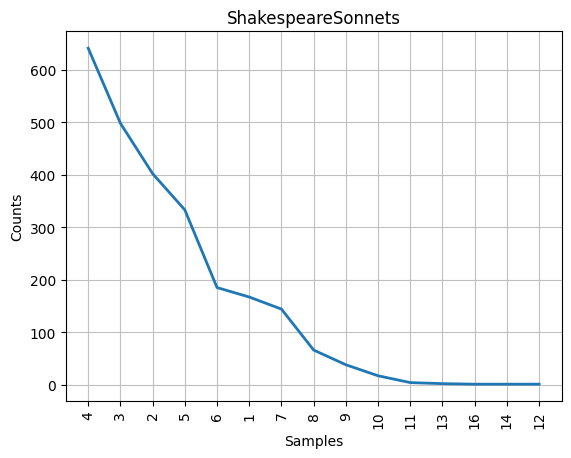

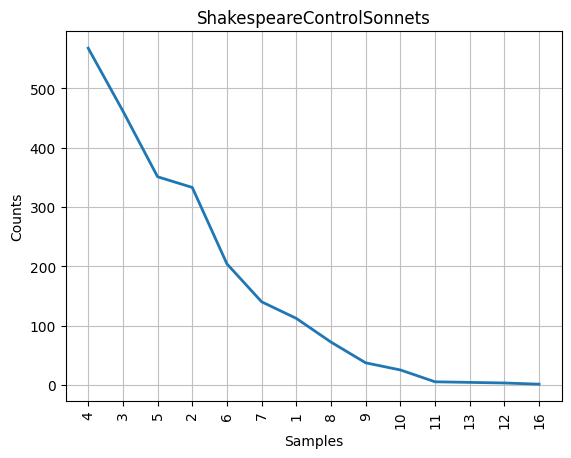

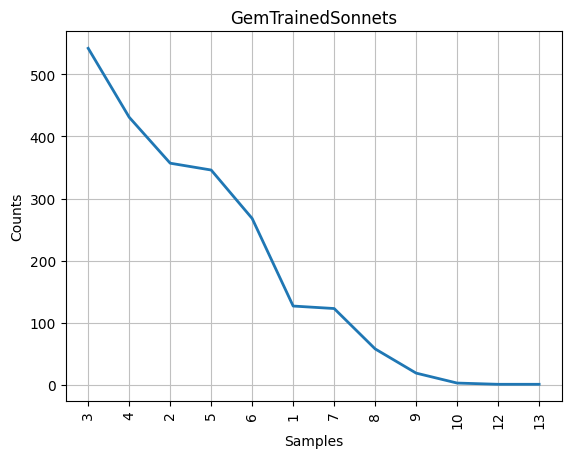

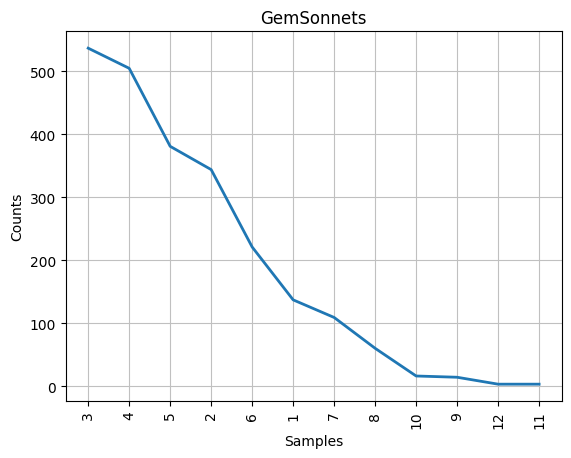

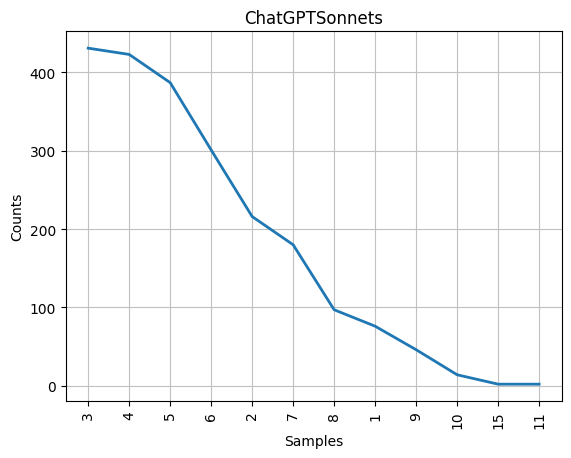

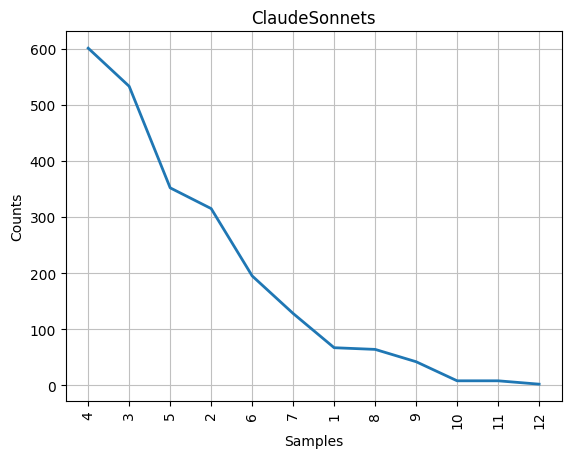

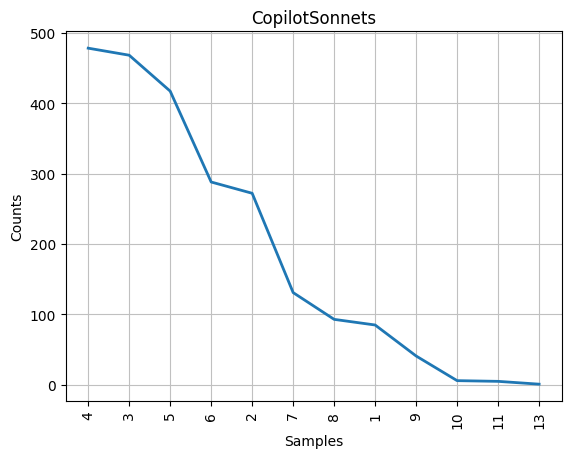

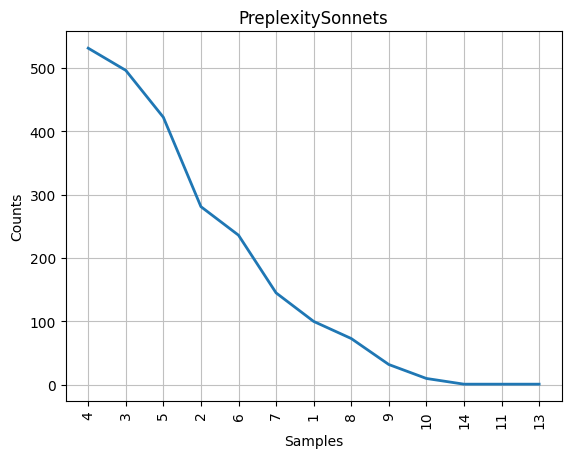

In [53]:
# Load nltk
import nltk
nltk.download(['punkt', 'punkt_tab'])
import matplotlib.pyplot as plt
%matplotlib inline

# Compare the disputed papers to those written by everyone,
# including the shared ones.
authors = ("ShakespeareSonnets", "ShakespeareControlSonnets", "GemTrainedSonnets", "GemSonnets",
           "ChatGPTSonnets", "ClaudeSonnets", "CopilotSonnets", "PreplexitySonnets")

# Transform the authors' corpora into lists of word tokens
by_author_tokens = {}
by_author_length_distributions = {}
for author in authors:
    tokens = nltk.word_tokenize(by_author[author])

    # Filter out punctuation
    by_author_tokens[author] = ([token for token in tokens
                                            if any(c.isalpha() for c in token)])

    # Get a distribution of token lengths
    token_lengths = [len(token) for token in by_author_tokens[author]]
    by_author_length_distributions[author] = nltk.FreqDist(token_lengths)
    plt.figure()
    by_author_length_distributions[author].plot(15,title=author)


In [54]:
# Who are the authors we are analyzing?
authors = ("ShakespeareControlSonnets", "GemTrainedSonnets", "GemSonnets", 
           "ChatGPTSonnets", "ClaudeSonnets", "CopilotSonnets", "PreplexitySonnets")

# Lowercase the tokens so that the same word, capitalized or not,
# counts as one word
for author in authors:
    by_author_tokens[author] = (
        [token.lower() for token in by_author_tokens[author]])
by_author_tokens["ShakespeareSonnets"] = (
    [token.lower() for token in by_author_tokens["ShakespeareSonnets"]])

# Calculate chisquared for each of the two candidate authors
for author in authors:

    # First, build a joint corpus and identify the 500 most frequent words in it
    joint_corpus = (by_author_tokens[author] +
                    by_author_tokens["ShakespeareSonnets"])
    joint_freq_dist = nltk.FreqDist(joint_corpus)
    most_common = list(joint_freq_dist.most_common(500))

    # What proportion of the joint corpus is made up
    # of the candidate author's tokens?
    author_share = (len(by_author_tokens[author])
                    / len(joint_corpus))

    # Now, let's look at the 500 most common words in the candidate
    # author's corpus and compare the number of times they can be observed
    # to what would be expected if the author's papers
    # and the Disputed papers were both random samples from the same distribution.
    chisquared = 0
    for word,joint_count in most_common:

        # How often do we really see this common word?
        author_count = by_author_tokens[author].count(word)
        disputed_count = by_author_tokens["ShakespeareSonnets"].count(word)

        # How often should we see it?
        expected_author_count = joint_count * author_share
        expected_disputed_count = joint_count * (1-author_share)

        # Add the word's contribution to the chi-squared statistic
        chisquared += ((author_count-expected_author_count) *
                       (author_count-expected_author_count) /
                       expected_author_count)

        chisquared += ((disputed_count-expected_disputed_count) *
                       (disputed_count-expected_disputed_count)
                       / expected_disputed_count)

    print("The Chi-squared statistic for candidate", author, "is", chisquared)


The Chi-squared statistic for candidate ShakespeareControlSonnets is 792.2512178090883
The Chi-squared statistic for candidate GemTrainedSonnets is 1270.7776834935112
The Chi-squared statistic for candidate GemSonnets is 1022.7298859466543
The Chi-squared statistic for candidate ChatGPTSonnets is 1196.9507410491085
The Chi-squared statistic for candidate ClaudeSonnets is 1022.369769346006
The Chi-squared statistic for candidate CopilotSonnets is 1450.1724399805685
The Chi-squared statistic for candidate PreplexitySonnets is 1132.1578324491195


In [51]:
# Who are we dealing with this time?
authors = ("ShakespeareControlSonnets", "GemTrainedSonnets", "GemSonnets",
           "ChatGPTSonnets", "ClaudeSonnets", "CopilotSonnets", "PreplexitySonnets")

# Convert papers to lowercase to count all tokens of the same word together
# regardless of case
for author in authors:
    by_author_tokens[author] = (
        [tok.lower() for tok in by_author_tokens[author]])

# Combine every paper except our test case into a single corpus
whole_corpus = []
for author in authors:
    whole_corpus += by_author_tokens[author]

# Get a frequency distribution
whole_corpus_freq_dist = list(nltk.FreqDist(whole_corpus).most_common(30))
whole_corpus_freq_dist[ :10 ]

# The main data structure
features = [word for word,freq in whole_corpus_freq_dist]
feature_freqs = {}

for author in authors:
    # A dictionary for each candidate's features
    feature_freqs[author] = {}

    # A helper value containing the number of tokens in the author's subcorpus
    overall = len(by_author_tokens[author])

    # Calculate each feature's presence in the subcorpus
    for feature in features:
        presence = by_author_tokens[author].count(feature)
        feature_freqs[author][feature] = presence / overall


import math

# The data structure into which we will be storing the "corpus standard" statistics
corpus_features = {}

# For each feature...
for feature in features:
    # Create a sub-dictionary that will contain the feature's mean
    # and standard deviation
    corpus_features[feature] = {}

    # Calculate the mean of the frequencies expressed in the subcorpora
    feature_average = 0
    for author in authors:
        feature_average += feature_freqs[author][feature]
    feature_average /= len(authors)
    corpus_features[feature]["Mean"] = feature_average

    # Calculate the standard deviation using the basic formula for a sample
    feature_stdev = 0
    for author in authors:
        diff = feature_freqs[author][feature] - corpus_features[feature]["Mean"]
        feature_stdev += diff*diff
    feature_stdev /= (len(authors) - 1)
    feature_stdev = math.sqrt(feature_stdev)
    corpus_features[feature]["StdDev"] = feature_stdev


feature_zscores = {}
for author in authors:
    feature_zscores[author] = {}
    for feature in features:

        # Z-score definition = (value - mean) / stddev
        # We use intermediate variables to make the code easier to read
        feature_val = feature_freqs[author][feature]
        feature_mean = corpus_features[feature]["Mean"]
        feature_stdev = corpus_features[feature]["StdDev"]
        feature_zscores[author][feature] = ((feature_val-feature_mean) /
                                            feature_stdev)

# Tokenize the test case
testcase_tokens = nltk.word_tokenize(by_author["ShakespeareSonnets"])

# Filter out punctuation and lowercase the tokens
testcase_tokens = [token.lower() for token in testcase_tokens
                   if any(c.isalpha() for c in token)]

# Calculate the test case's features
overall = len(testcase_tokens)
testcase_freqs = {}
for feature in features:
    presence = testcase_tokens.count(feature)
    testcase_freqs[feature] = presence / overall

# Calculate the test case's feature z-scores
testcase_zscores = {}
for feature in features:
    feature_val = testcase_freqs[feature]
    feature_mean = corpus_features[feature]["Mean"]
    feature_stdev = corpus_features[feature]["StdDev"]
    testcase_zscores[feature] = (feature_val - feature_mean) / feature_stdev

for author in authors:
    delta = 0
    for feature in features:
        delta += math.fabs((testcase_zscores[feature] -
                            feature_zscores[author][feature]))
    delta /= len(features)
    print( "Delta score for candidate", author, "is", delta )



Delta score for candidate ShakespeareControlSonnets is 0.8609128967703968
Delta score for candidate GemTrainedSonnets is 1.2887181712696687
Delta score for candidate GemSonnets is 1.017492382288795
Delta score for candidate ChatGPTSonnets is 1.139514256837603
Delta score for candidate ClaudeSonnets is 1.0385529073829074
Delta score for candidate CopilotSonnets is 1.5323756296446043
Delta score for candidate PreplexitySonnets is 1.0704354353125671
